# Basic Data Exploration

In [26]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

from lana_nlp.analysis.lyrics_analyzer import LyricsAnalyzer
from lana_nlp.features.vocabulary import VocabularyAnalyzer
from lana_nlp.features.readability import ReadabilityAnalyzer
from lana_nlp.features.sentiment import SentimentAnalyzer

In [2]:
df = pd.read_csv("../data/processed/lyrics.csv")

In [3]:
analyzer = LyricsAnalyzer(
    df,
    basic_text_column="basic_cleaned_lyrics",
    nlp_text_column="nlp_cleaned_lyrics",
)

df = analyzer.analyze()

In [4]:
df.shape

(154, 13)

In [5]:
df["album"].value_counts()

album
Ultraviolence                                          16
Lust for Life                                          16
Did You Know That There's a Tunnel Under Ocean Blvd    16
Sirens                                                 15
Born To Die                                            15
Blue Banisters                                         15
Honeymoon                                              14
Norman Fucking Rockwell!                               14
Lana Del Ray, A.K.A. Lizzy Grant                       13
Chemtrails Over the Country Club                       11
Paradise                                                9
Name: count, dtype: int64

In [6]:
print(f"Min Year: {df['year'].min()}")
print(f"Max Year: {df['year'].max()}")

Min Year: 2006
Max Year: 2023


In [7]:
df.columns.tolist()

['Unnamed: 0',
 'artist',
 'album',
 'song',
 'year',
 'lyrics',
 'basic_cleaned_lyrics',
 'nlp_cleaned_lyrics',
 'word_count',
 'unique_words',
 'syllable_count',
 'line_count',
 'reading_minutes']

## Album Statistics

In [8]:
album_summary = analyzer.statistics.summary_by_album()
# album_summary.head(11)

album_summary.sort_values(
    "avg_words",
    ascending=False
)

,songs,avg_words,median_words,min_words,max_words,total_words,avg_reading_minutes
album,,,,,,,
Born To Die,15,403.866667,395.0,254,600,6058,2.019333
Did You Know That There's a Tunnel Under Ocean Blvd,16,377.437500,338.5,188,749,6039,1.887188
Lust for Life,16,357.562500,354.0,207,613,5721,1.787813
Norman Fucking Rockwell!,14,332.285714,313.0,196,478,4652,1.661429
Chemtrails Over the Country Club,11,310.545455,317.0,171,402,3416,1.552727
Blue Banisters,15,279.266667,293.0,0,436,4189,1.396333
Paradise,9,277.777778,290.0,90,408,2500,1.388889
Ultraviolence,16,273.062500,263.5,126,395,4369,1.365312
Honeymoon,14,270.285714,270.0,84,411,3784,1.351429


In [9]:
album_summary.columns.tolist()

['songs',
 'avg_words',
 'median_words',
 'min_words',
 'max_words',
 'total_words',
 'avg_reading_minutes']

## Average Words per Song by Album

Are her songs getting longer over time?

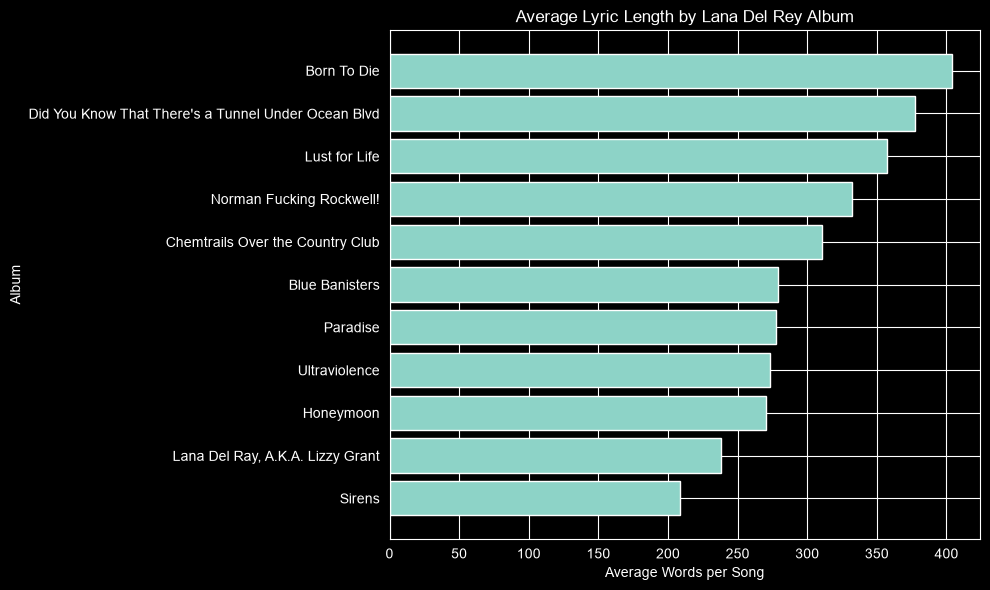

In [10]:
album_words = album_summary.sort_values("avg_words")

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    album_words.index,
    album_words["avg_words"]
)

plt.xlabel("Average Words per Song")
plt.ylabel("Album")
plt.title("Average Lyric Length by Lana Del Rey Album")

plt.tight_layout()
plt.show()

In [23]:
album_years = (
    df.groupby("album")["year"]
    .min()
)

album_summary["year"] = album_years

chronological = album_summary.sort_values("year")

# chronological[["year", "avg_words"]]

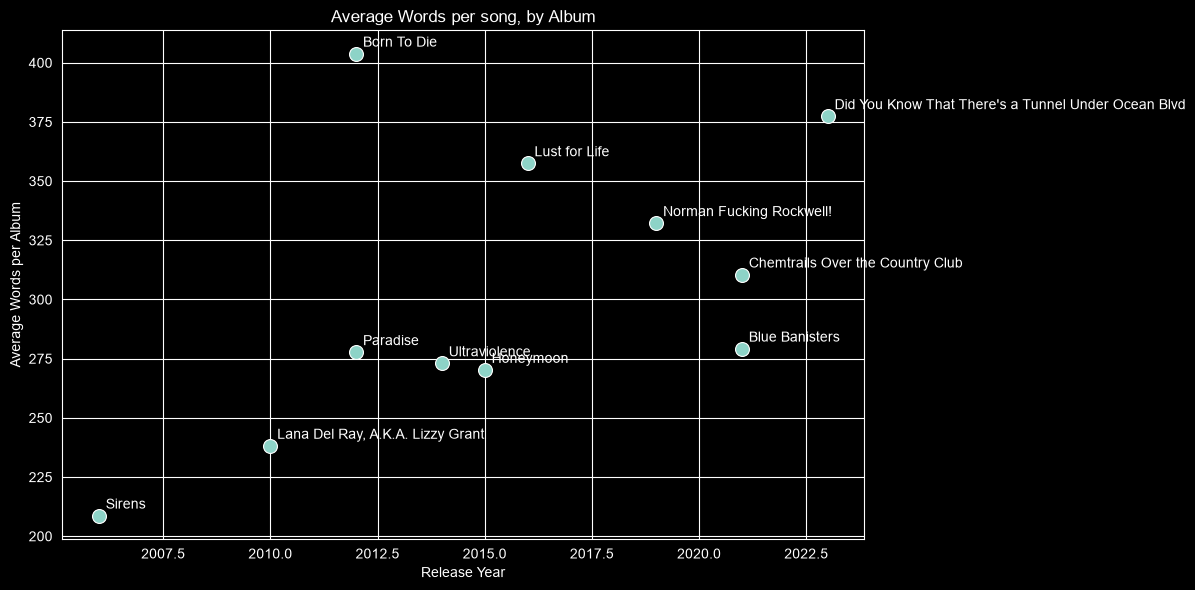

In [24]:
plt.figure(
    figsize=(12, 6)
)

sns.scatterplot(
    data=chronological,
    x="year",
    y="avg_words",
    s=100
)

for album, row in chronological.iterrows():
    plt.annotate(
        album,
        (row["year"], row["avg_words"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.xlabel("Release Year")
plt.ylabel("Average Words per Album")
plt.title("Average Words per song, by Album")

plt.tight_layout()
plt.show()

Average lyrical length increased across Lana Del Rey's discography. Born To Die looks like it could be an outlier.


### Does Born To Die have wordier lyric sections in general?

This would be in comparison to albums that were made around the same time period (Paradise, Ultraviolence, and Honeymoon). All of these had significantly less average words per song than Born To Die.


In [13]:
# Calculate words per line column
df["words_per_line"] = (
    df["word_count"] / df["line_count"].replace(0, pd.NA)
)

df.groupby("album")["words_per_line"].mean().sort_values()

album
Paradise                                               5.583152
Lana Del Ray, A.K.A. Lizzy Grant                         5.7268
Lust for Life                                          6.057829
Blue Banisters                                         6.091362
Ultraviolence                                           6.11597
Did You Know That There's a Tunnel Under Ocean Blvd    6.123504
Honeymoon                                              6.136474
Chemtrails Over the Country Club                       6.167297
Norman Fucking Rockwell!                               6.499715
Sirens                                                 6.745097
Born To Die                                            7.159159
Name: words_per_line, dtype: object

Born To Die does appear to be wordier, but this may not be the best statistic to see what is happening with this album. For example, Lust for Life had a high average word count, but is one of the least wordy albums (based on word count / line count).

## Lexical Diversity over Time

Is she using a more varied vocabulary?

In [14]:
df["lexical_diversity"] = df["nlp_cleaned_lyrics"].apply(
    lambda lyrics: VocabularyAnalyzer(
        pd.DataFrame({"lyrics": [lyrics]}),
    ).lexical_diversity()
)

album_lexical_diversity = (
    df.groupby(["album", "year"])["lexical_diversity"]
      .mean()
      .reset_index()
      .sort_values("year")
)

album_lexical_diversity

,album,year,lexical_diversity
9,Sirens,2006,0.586279
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,0.412587
8,Paradise,2012,0.457520
1,Born To Die,2012,0.433940
10,Ultraviolence,2014,0.438249
4,Honeymoon,2015,0.470715
6,Lust for Life,2016,0.460937
7,Norman Fucking Rockwell!,2019,0.509134
0,Blue Banisters,2021,0.530742
2,Chemtrails Over the Country Club,2021,0.491269


In [15]:
fig = px.scatter(
    album_lexical_diversity,
    x="year",
    y="lexical_diversity",
    hover_name="album",
    hover_data={
        "year": True,
        "lexical_diversity": ":.3f"
    },
    labels={
        "year": "Year",
        "lexical_diversity": "Lyrics Diversity",
    },
    title="Lana Del Rey's Lexical Diversity Over Time"
)

fig.show()

Lexical diversity is defined as unique words / total words. So a higher lexical diversity means the albums uses the same words more often. Lizzy's first album, Sirens, was more repetitive than everything that came after. This could be due to it being her first album. She wouldn't have had the life or industry experience yet.

Surprisingly, Born To Die had lower lexical diversity even though it had the longest songs by word count overall.

Lexical Diversity tended to decrease overall throughout Lana's career. Maybe the albums became more targeted with clear trends.

## Average Word Length (How Complex is the Vocabulary?)

In [16]:
df["average_word_length"] = df["nlp_cleaned_lyrics"].apply(
    lambda lyrics: VocabularyAnalyzer(
        pd.DataFrame({"lyrics": [lyrics]}),
    ).average_word_length()
)

album_word_length = (
    df.groupby(["album", "year"])["average_word_length"]
      .mean()
      .reset_index()
      .sort_values("year")
)

In [17]:
fig = px.scatter(
    album_word_length,
    x="year",
    y="average_word_length",
    hover_name="album",
    hover_data={
        "year": True,
        "average_word_length": ":.3f"
    },
    labels={
        "year": "Year",
        "average_word_length": "Avg Word Length",
    },
    title="Lana Del Rey's Word Length Over Time"
)

fig.show()

Average word length tends to increase overtime, but it seems fairly flat. I would need more artists in order to compare significance. Blue Banisters uses much shorter words than most of her albums.

## Readability

How hard are the lyrics to read?

In [18]:
readability = ReadabilityAnalyzer(
    df,
    text_column="lyrics"
)

readability.flesch_reading_ease()

album_readability = (
    df.groupby(["album", "year"])["flesch_reading_ease"]
      .mean()
      .reset_index()
      .sort_values("year")
)

fig = px.scatter(
    album_readability,
    x="year",
    y="flesch_reading_ease",
    hover_name="album",
    hover_data={
        "year": True,
        "flesch_reading_ease": ":.2f",
    },
    labels={
        "year": "Year",
        "flesch_reading_ease": "Flesch Reading Ease",
    },
    title="Lana Del Rey's Lyrics: Readability Over Time",
)

fig.show()

In [22]:
df.groupby("album").agg(
    avg_words=("word_count", "mean"),
    avg_lines=("line_count", "mean"),
    avg_readability=("flesch_reading_ease", "mean")
)

,avg_words,avg_lines,avg_readability
album,,,
Blue Banisters,279.266667,46.133333,-84.740835
Born To Die,403.866667,56.466667,-35.660368
Chemtrails Over the Country Club,310.545455,50.909091,-62.612590
Did You Know That There's a Tunnel Under Ocean Blvd,377.437500,61.875000,-38.457888
Honeymoon,270.285714,46.714286,-100.305090
"Lana Del Ray, A.K.A. Lizzy Grant",238.230769,41.923077,-38.624222
Lust for Life,357.562500,58.562500,-66.456850
Norman Fucking Rockwell!,332.285714,54.000000,-141.078447
Paradise,277.777778,49.222222,-125.825139


In [20]:
df[df["album"] == "Born To Die"][
    ["song", "word_count", "line_count", "flesch_reading_ease"]
]


,song,word_count,line_count,flesch_reading_ease
28,Born to Die,478,67,-7.375910
29,Off to the Races,600,71,-100.223000
30,Blue Jeans,397,51,5.940079
31,Video Games,390,54,8.955577
32,Diet Mountain Dew,562,69,81.629192
33,National Anthem,484,67,-3.634355
34,Dark Paradise,396,59,-305.555000
35,Radio,395,62,62.438196
36,Carmen,345,60,-256.670765
37,Million Dollar Man,254,33,70.690640


In [21]:
df.loc[
    df["song"] == "Born to Die",
    ["lyrics", "nlp_cleaned_lyrics"]
].iloc[0]

lyrics                Why? (Got that?)\nWho, me? (Louder)\nWhy? (Got...
nlp_cleaned_lyrics    ['got', 'louder', 'got', 'foot', 'dont', 'fail...
Name: 28, dtype: str

Come back to this because there maybe be a better way to clean lyrics for flesh reading ease or there may be a better metric to use.

## Sentiment

In [29]:
sentiment = SentimentAnalyzer(df)

sentiment.sentiment_polarity()

album_sentiment = (
    df.groupby(["album", "year"])
      .agg(
        avg_sentiment=("sentiment", "mean")
    )
    .reset_index()
    .sort_values("year")
)

album_sentiment

,album,year,avg_sentiment
9,Sirens,2006,0.528500
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,0.722008
8,Paradise,2012,0.761322
1,Born To Die,2012,0.743980
10,Ultraviolence,2014,0.558800
4,Honeymoon,2015,0.419186
6,Lust for Life,2016,0.618906
7,Norman Fucking Rockwell!,2019,0.593614
0,Blue Banisters,2021,0.715173
2,Chemtrails Over the Country Club,2021,0.808591
